In [ ]:
import pandas as pd

# قراءة ملف البيانات
df = pd.read_excel("decodelabes-internship.xlsx")

# عرض الإحصاءات الأساسية والأرقام الخمسة للأعمدة الرقمية
print("--- ملخص الأرقام الخمسة والإحصاءات الأساسية ---")
print(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe())

--- ملخص الأرقام الخمسة والإحصاءات الأساسية ---
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


--- اكتشاف القيم الشاذة ---
عدد القيم الشاذة المكتشفة: 8
أي طلب يتخطى هذا السعر يعتبر شاذ: $3330.41



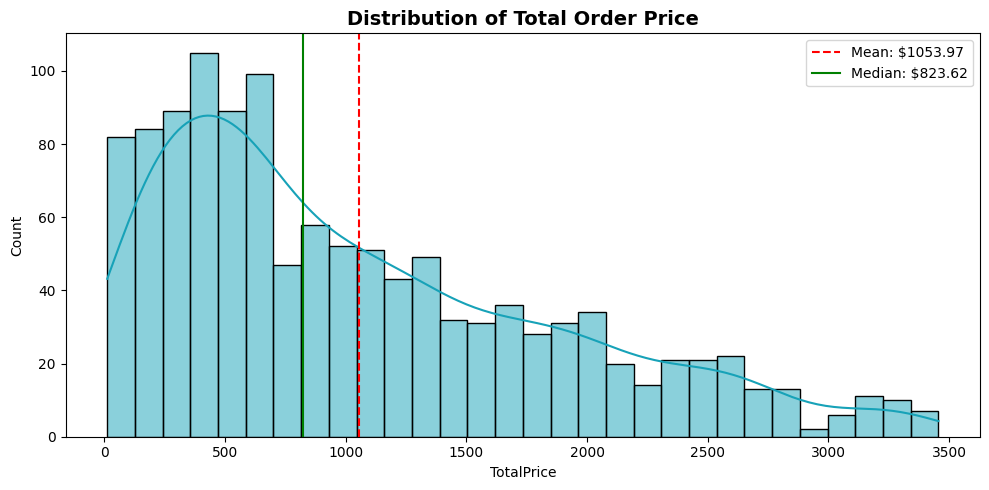

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# حساب قيم الـ IQR لتحديد القيم الشاذة في إجمالي السعر
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['TotalPrice'] > upper_bound]
print(f"--- اكتشاف القيم الشاذة ---")
print(f"عدد القيم الشاذة المكتشفة: {len(outliers)}")
print(f"أي طلب يتخطى هذا السعر يعتبر شاذ: ${upper_bound:.2f}\n")

# رسم منحنى التوزيع (Distribution Plot) لرؤية شكل البيانات
plt.figure(figsize=(10, 5))
sns.histplot(df['TotalPrice'], kde=True, color='#17a2b8', bins=30)
plt.title('Distribution of Total Order Price', fontsize=14, fontweight='bold')
plt.axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label=f"Mean: ${df['TotalPrice'].mean():.2f}")
plt.axvline(df['TotalPrice'].median(), color='green', linestyle='-', label=f"Median: ${df['TotalPrice'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

--- إجمالي الإيرادات حسب نوع المنتج ---
   Product  TotalPrice
0    Chair   195620.11
1  Printer   195612.61
2   Laptop   192126.56
3   Tablet   186568.95
4  Monitor   175651.41
5     Desk   167459.93
6    Phone   151722.39


C:\Users\4B\AppData\Local\Temp\ipykernel_2192\1033719604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales, x='TotalPrice', y='Product', palette='Blues_r')


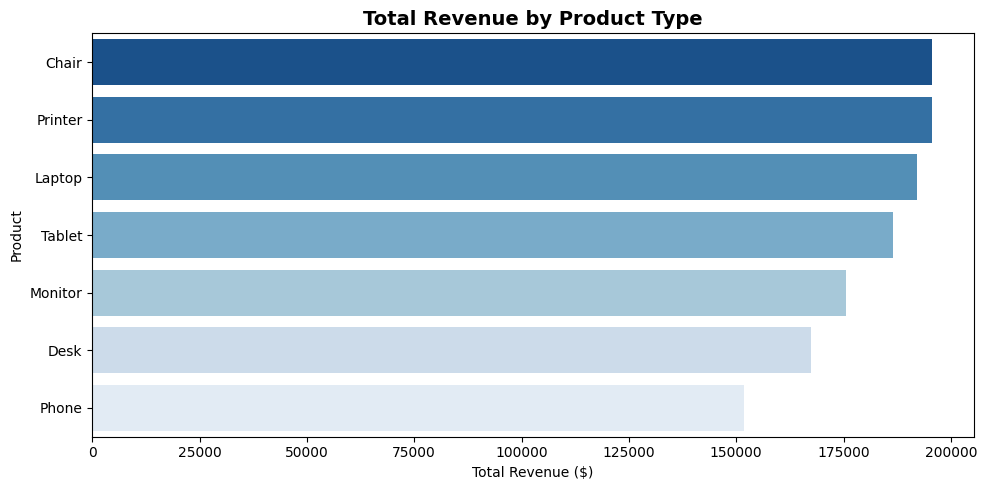

In [5]:
# حساب إجمالي الإيرادات مالياً لكل منتج
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
print("--- إجمالي الإيرادات حسب نوع المنتج ---")
print(product_sales)

# رسم بياني مبسط وواضح (Bar Chart)
plt.figure(figsize=(10, 5))
sns.barplot(data=product_sales, x='TotalPrice', y='Product', palette='Blues_r')
plt.title('Total Revenue by Product Type', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()